In [1]:
import geopandas as gpd

In [2]:
salina_basins = gpd.read_file("../data/processed/basins/salina_basins.gpkg")

In [3]:
basins = "../data/processed/basins/basin_counties_us.gpkg"
basins = gpd.read_file(basins)

<Axes: >

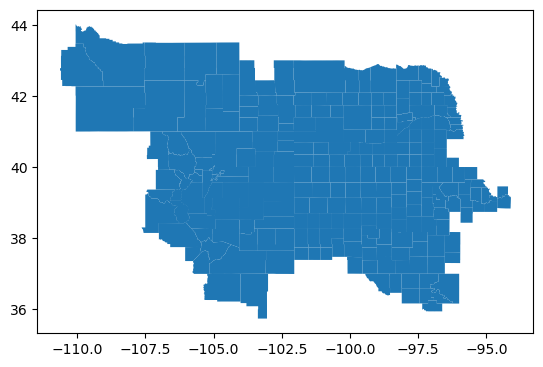

In [4]:
basins.plot()

In [5]:
basins.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
import pandas as pd

In [7]:
pop_df = pd.read_csv("../data/raw/bea/population.csv")
pop_df['GeoFIPS'] = pop_df['GeoFIPS'].astype(str).apply(lambda x: x.zfill(5))

In [8]:
pop_df.head()

,GeoFIPS,GeoName,Region,TableName,LineCode,IndustryClassification,Description,Unit,1969,1970,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,00000,United States,,CAINC4,20,...,Population (persons) 3/,Number of persons,201298000,203798722,...,316735375,319270047,321829327,324367742,326623063,328542157,330233102,331511512,332031554,333287557
1,01000,Alabama,5,CAINC4,20,...,Population (persons) 3/,Number of persons,3440000,3449846,...,4864399,4886793,4908162,4930595,4952202,4976395,5003418,5031362,5049846,5074296
2,01001,"Autauga, AL",5,CAINC4,20,...,Population (persons) 3/,Number of persons,25166,24606,...,55594,56034,56278,56954,57371,57728,58245,58902,59210,59759
3,01003,"Baldwin, AL",5,CAINC4,20,...,Population (persons) 3/,Number of persons,56951,59474,...,196067,200759,204925,210004,215365,221132,227079,233219,239361,246435
4,01005,"Barbour, AL",5,CAINC4,20,...,Population (persons) 3/,Number of persons,23818,22655,...,27158,27043,26633,26217,25608,25380,25205,24960,24539,24706


In [9]:
basins.head()

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,40,119,01101847,0500000US40119,40119,Payne,06,1773393751,31771426,"MULTIPOLYGON (((-97.35414 36.15907, -97.32717 ..."
1,40,047,01101811,0500000US40047,40047,Garfield,06,2741479095,4075930,"MULTIPOLYGON (((-98.10444 36.26037, -98.10443 ..."
2,40,103,01101839,0500000US40103,40103,Noble,06,1895576674,27569163,"MULTIPOLYGON (((-97.46161 36.59363, -97.36375 ..."
3,40,151,01101863,0500000US40151,40151,Woods,06,3331900090,9091699,"MULTIPOLYGON (((-99.45621 36.99947, -99.40702 ..."
4,40,003,01101789,0500000US40003,40003,Alfalfa,06,2244107619,38546676,"MULTIPOLYGON (((-98.54466 36.999, -98.47641 36..."


In [10]:
merged = pd.merge(basins, pop_df, left_on='GEOID', right_on='GeoFIPS')

In [11]:
merged

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,40,119,01101847,0500000US40119,40119,Payne,06,1773393751,31771426,"MULTIPOLYGON (((-97.35414 36.15907, -97.32717 ...",...,79712,80536,81379,81842,81899,82080,81543,81645,82149,82794
1,40,047,01101811,0500000US40047,40047,Garfield,06,2741479095,4075930,"MULTIPOLYGON (((-98.10444 36.26037, -98.10443 ...",...,62948,63563,64191,63696,62990,62703,62936,62692,61947,61920
2,40,103,01101839,0500000US40103,40103,Noble,06,1895576674,27569163,"MULTIPOLYGON (((-97.46161 36.59363, -97.36375 ...",...,11360,11466,11449,11288,11159,11131,10976,10922,10942,10896
3,40,151,01101863,0500000US40151,40151,Woods,06,3331900090,9091699,"MULTIPOLYGON (((-99.45621 36.99947, -99.40702 ...",...,8972,9211,9253,9090,8997,8791,8700,8598,8613,8587
4,40,003,01101789,0500000US40003,40003,Alfalfa,06,2244107619,38546676,"MULTIPOLYGON (((-98.54466 36.999, -98.47641 36...",...,5851,5816,5910,5924,5902,5739,5661,5708,5681,5637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,31,149,00835896,0500000US31149,31149,Rock,06,2611466192,8807741,"MULTIPOLYGON (((-99.67768 42.7309, -99.67205 4...",...,1402,1400,1358,1335,1339,1267,1272,1266,1271,1245
279,31,017,00835830,0500000US31017,31017,Brown,06,3163296262,9814399,"MULTIPOLYGON (((-100.19852 42.81052, -100.1985...",...,2936,2944,2946,2934,2951,2901,2897,2902,2912,2872
280,31,031,00835837,0500000US31031,31031,Cherry,06,15436868252,127452878,"MULTIPOLYGON (((-102.08414 42.87246, -102.0825...",...,5657,5616,5666,5650,5591,5544,5473,5454,5447,5464
281,31,043,00835843,0500000US31043,31043,Dakota,06,684422627,8193327,"MULTIPOLYGON (((-96.72662 42.28042, -96.72661 ...",...,21224,21145,21292,21174,21086,21235,21400,21552,21256,21042


In [12]:
merged = merged.to_crs(merged.estimate_utm_crs())

In [13]:
merged.area.sum()

np.float64(873918978837.7693)

In [14]:
merged['2022'].sum()

'827946192010896858756374124532341221575745839436683445324411681193324043576719733848224737193906752552561516399333801940730012250805729273938553765017556179264515562064501468240593925481186829273980122463432360314327165921963708218303539911854243053356623169544561414244962112232022374056717322485755101726716876635517939277997327696137598855285940730012250802645155620645014118681565453491843029272752289412717270524112425481378935301122317321488551061919511996471653116574682892183442570331610863555359666392899579534905738894628983533701917748035691711082627380431328610115998255012689480925284575105732598305489888492633936425287154215831411646424885404128733336669060493097055536209732475617692842718082829336858269143549429516627799696158302583481298991590377244492082322952022374056724857551089882633215831411666903097062097324756176922712219655323118842758632718085058628292388433685826910476675372453942977216515298051663326342964073222721167104443699767558929650798715385180178535368571762

In [15]:
merged[['2022']].sum()

2022    8279461920108968587563741245323412215757458394...
dtype: str

In [16]:
merged.dtypes

STATEFP     str
COUNTYFP    str
COUNTYNS    str
AFFGEOID    str
GEOID       str
           ... 
2018        str
2019        str
2020        str
2021        str
2022        str
Length: 72, dtype: object

In [17]:
merged['pop2022'] = merged[['2022']].astype(int)

In [18]:
merged.pop2022.sum() # total population for all counties

np.int64(13498362)

In [19]:
merged.STATEFP.unique()

<StringArray>
['40', '20', '35', '08', '29', '31', '56']
Length: 7, dtype: str

In [20]:
import tobler

In [21]:
source = merged[['geometry', 'pop2022']]

In [22]:
source.crs

<Projected CRS: EPSG:32613>
Name: WGS 84 / UTM zone 13N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 108°W and 102°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Northwest Territories (NWT); Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-108.0, 0.0, -102.0, 84.0)
Coordinate Operation:
- name: UTM zone 13N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [23]:
salina_basins.crs

<Projected CRS: EPSG:32614>
Name: WGS 84 / UTM zone 14N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 102°W and 96°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Manitoba; Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-102.0, 0.0, -96.0, 84.0)
Coordinate Operation:
- name: UTM zone 14N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [24]:
source = source.to_crs(salina_basins.crs)

In [25]:
estimates = tobler.area_weighted.area_interpolate(source_df = source, 
                                                  target_df=salina_basins, extensive_variables=['pop2022'])

estimates

/home/serge/projects/dev-rampr/.pixi/envs/default/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


,pop2022,geometry
0,3.269838e+06,"POLYGON ((64983.046 4106054.08, 64765.09 41060..."
1,3.033575e+06,"POLYGON ((740917.309 4300553.528, 740705.599 4..."
2,7.194949e+06,"POLYGON ((-131296.491 4803076.853, -131141.21 ..."


## Don't allocate totals if counties have area outside of the basin

In [26]:
estimates = tobler.area_weighted.area_interpolate(source_df = source, 
                                                  target_df=salina_basins, extensive_variables=['pop2022'],
                                                 allocate_total=False)

estimates

/home/serge/projects/dev-rampr/.pixi/envs/default/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


,pop2022,geometry
0,2.930443e+06,"POLYGON ((64983.046 4106054.08, 64765.09 41060..."
1,1.602080e+06,"POLYGON ((740917.309 4300553.528, 740705.599 4..."
2,6.318528e+06,"POLYGON ((-131296.491 4803076.853, -131141.21 ..."
